In [1]:
import pandas as pd
import gzip
from pathlib import Path
 
# 1. Define paths
data_dir = Path("../../data/snvs/filtered_denominator_v2")
master_list_path = data_dir / "master_list.csv"

# 2. Load metadata
df_meta = pd.read_csv(master_list_path)

# Ensure LEGACY and UKCTOCS are grouped as 'PBMCs' (if they aren't already in the CSV)
# This looks for sample IDs starting with either name and forces the sample_type
mask_pbmc = df_meta['sample_id'].str.startswith('UKCTOCS') | df_meta['sample_id'].str.startswith('LEGACY')
df_meta.loc[mask_pbmc, 'sample_type'] = 'PBMCs'

# Helper function to parse VCF and extract INFO fields
def parse_vcf_variants(vcf_file):
    variants = []
    with gzip.open(vcf_file, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            parts = line.strip().split('\t')
            if len(parts) < 8:
                continue
            
            chrom = parts[0]
            pos = int(parts[1])
            ref = parts[3]
            alts = parts[4].split(',') # Take the first ALT if there are multiple
            alt = alts[0]
            
            # Only keep Single Nucleotide Variants
            if len(ref) != 1 or len(alt) != 1:
                continue
                
            info_field = parts[7]
            n_alt, n_total = None, None
            for item in info_field.split(';'):
                if item.startswith('N_ALT='):
                    n_alt = float(item.split('=')[1])
                elif item.startswith('N_TOTAL='):
                    n_total = float(item.split('=')[1])
            
            if n_alt is not None and n_total is not None and n_total > 0:
                variants.append({
                    'CHROM': chrom,
                    'POS': pos,
                    'REF': ref,
                    'ALT': alt,
                    'VAF': n_alt / n_total,
                    'DEPTH': n_total
                })
                
    return pd.DataFrame(variants)

# 3. Process all samples
all_variants_list = []
burden_summary_list = []

print("Loading VCFs and calculating burden...")

for _, row in df_meta.iterrows():
    sample_id = row['sample_id']
    
    # Dynamically find the VCF file in the ../Data directory based on sample_id
    search_pattern = f"{sample_id}_annotated.filtered.vcf.gz"
    found_files = list(data_dir.rglob(search_pattern))
    
    if not found_files:
        print(f"  [Warning] VCF not found for {sample_id}. Skipping.")
        continue
        
    vcf_path = found_files[0] # Take the first match
    
    # Parse the variants for this sample
    df_sample_vars = parse_vcf_variants(vcf_path)
    mutation_count = len(df_sample_vars)
    
    # --- Create a summary for Burden Plotting ---
    burden_summary_list.append({
        'sample_id': sample_id,
        'sample_type': row['sample_type'],
        'age': row['age'],
        'bases': row['total_callable_bases_in_wes'],
        'effective_territory': row['effective_territory'],
        'mutation_count': mutation_count,
        # Normalizing mutation count per Megabase (using sequenced bases or territory)
        'mutations_per_mb_sequenced': mutation_count / (row['total_callable_bases_in_wes'] / 1e6) if row['total_callable_bases_in_wes'] > 0 else 0
    })
    
    # --- Create a detailed DataFrame of ALL variants (useful later for signatures) ---
    if not df_sample_vars.empty:
        df_sample_vars['sample_id'] = sample_id
        df_sample_vars['sample_type'] = row['sample_type']
        df_sample_vars['age'] = row['age']
        df_sample_vars['bases'] = row['total_callable_bases_in_wes']
        all_variants_list.append(df_sample_vars)

# 4. Finalize DataFrames
df_burden = pd.DataFrame(burden_summary_list)
df_variants = pd.concat(all_variants_list, ignore_index=True)

print(f"Successfully loaded {len(df_burden)} samples.")
display(df_burden.head())

Loading VCFs and calculating burden...
Successfully loaded 36 samples.


,sample_id,sample_type,age,bases,effective_territory,mutation_count,mutations_per_mb_sequenced
0,27YO_UDI5,T_cells,27,1978103441,33817126,182,0.092007
1,27YO_UDI6,T_cells,27,2462100281,33817126,260,0.105601
2,UDI23_3x,T_cells,83,15138282907,33817126,3450,0.227899
3,UDI24_3x,T_cells,83,10554092498,33817126,2714,0.257151
4,UKCTOCS_UDI1,PBMCs,63,7626413040,33817126,910,0.119322


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr

# Load ATAC-seq data
atac_path = "../../data/atac_seq/GSE74912_ATACseq_All_Counts.txt" # Update path as needed
df_atac = pd.read_csv(atac_path, sep='\t')

# 1. Identify columns belonging to our cell types of interest
# You may need to tweak these list comprehensions depending on exact naming conventions
cd4_cols = [col for col in df_atac.columns if 'CD4' in col]
cd8_cols = [col for col in df_atac.columns if 'CD8' in col]

# For PBMCs, we might aggregate B-cells, NK-cells, Monocytes, Leukocytes, etc.
# Alternatively, if you have specific PBMC columns, filter for those.
pbmc_cols = [col for col in df_atac.columns if any(x in col for x in ['Bcell', 'Nkcell', 'Leuk'])]

# 2. Calculate mean accessibility signal for each cell type
df_atac['CD4_accessibility'] = df_atac[cd4_cols].mean(axis=1)
df_atac['CD8_accessibility'] = df_atac[cd8_cols].mean(axis=1)
df_atac['PBMCs_accessibility'] = df_atac[pbmc_cols].mean(axis=1)

# 3. Calculate the length of each ATAC peak (we need this for normalization)
df_atac['Peak_Length'] = df_atac['End'] - df_atac['Start']

# Format for PyRanges (requires Chromosome, Start, End)
df_atac = df_atac.rename(columns={'Chr': 'Chromosome'})

In [3]:
import pandas as pd
import numpy as np
import pyranges as pr

# 0. Ensure variants from CD4/CD8 are grouped as 'T_cells'
mask_tcells = df_variants['sample_type'].isin(['CD4', 'CD8'])
df_variants.loc[mask_tcells, 'sample_type'] = 'T_cells'

# 1. Expand the ATAC-seq peaks to create "Zones of Open Chromatin"
WINDOW_SIZE = 1000
df_atac_expanded = df_atac.copy()
# Prevent negative start coordinates
df_atac_expanded['Start'] = (df_atac_expanded['Start'] - WINDOW_SIZE).clip(lower=0) 
df_atac_expanded['End'] = df_atac_expanded['End'] + WINDOW_SIZE

# 2. Load WES capture space
wes_bed_path = "../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed"
df_wes = pd.read_csv(wes_bed_path, sep='\t', header=None, usecols=[0, 1, 2], names=['Chromosome', 'Start', 'End'])
pr_wes = pr.PyRanges(df_wes)

# 3. Intersect the EXPANDED ATAC zones with WES space
pr_atac = pr.PyRanges(df_atac_expanded)
pr_atac_wes = pr_atac.intersect(pr_wes)
df_atac_wes = pr_atac_wes.df

# Recalculate Peak Length based on the INTERSECTED coordinates
df_atac_wes['WES_Peak_Length'] = df_atac_wes['End'] - df_atac_wes['Start']

# 4. Group Cell Types: T_cells vs PBMCs
t_cell_cols = [col for col in df_atac_wes.columns if 'CD4' in col or 'CD8' in col]
pbmc_cols = [col for col in df_atac_wes.columns if any(x in col for x in ['Bcell', 'Nkcell', 'Leuk', 'PBMC'])]

# Force columns to numeric
df_atac_wes[t_cell_cols] = df_atac_wes[t_cell_cols].apply(pd.to_numeric, errors='coerce')
df_atac_wes[pbmc_cols] = df_atac_wes[pbmc_cols].apply(pd.to_numeric, errors='coerce')

# Calculate mean accessibility 
df_atac_wes['T_cells_accessibility'] = df_atac_wes[t_cell_cols].mean(axis=1)
df_atac_wes['PBMCs_accessibility'] = df_atac_wes[pbmc_cols].mean(axis=1)

print(f"Original ATAC peaks: {len(df_atac)} | WES-intersected Expanded Zones: {len(df_atac_wes)}")

Original ATAC peaks: 590650 | WES-intersected Expanded Zones: 211189


In [4]:
# 4. Generate Quintiles on the WES-restricted data
for cell_type in ['T_cells', 'PBMCs']:
    col_name = f"{cell_type}_accessibility"
    
    # We add a small random noise to prevent ValueError from duplicate bin edges 
    signal = df_atac_wes[col_name] + np.random.uniform(0, 1e-6, size=len(df_atac_wes))
    df_atac_wes[f'{cell_type}_Quintile'] = pd.qcut(signal, q=5, labels=['1_Closed', '2', '3', '4', '5_Open'])

# Convert the updated ATAC dataframe to a PyRanges object for fast variant intersection
pr_atac_wes_final = pr.PyRanges(df_atac_wes)

In [5]:
# Format your variants dataframe for PyRanges
df_variants_pr = df_variants.rename(columns={'CHROM': 'Chromosome'})
df_variants_pr['Start'] = df_variants_pr['POS'] - 1 
df_variants_pr['End'] = df_variants_pr['POS']       

pr_variants = pr.PyRanges(df_variants_pr)

# Intersect Variants with WES-restricted EXPANDED ATAC zones
annotated_variants = pr_variants.join(pr_atac_wes_final).df

# CRITICAL FIX: Because we expanded the ATAC peaks, they may now overlap. 
# A single variant falling into an overlap will be duplicated in the dataframe.
# We drop duplicates based on the specific mutation and sample.
annotated_variants = annotated_variants.drop_duplicates(
    subset=['Chromosome', 'Start', 'End', 'REF', 'ALT', 'sample_id']
)

print(f"Successfully annotated {len(annotated_variants)} unique variants with ATAC data.")

Successfully annotated 10835 unique variants with ATAC data.


In [23]:
def calculate_depth_normalized_rates(variants_df, atac_df, df_meta, variant_cell_type, atac_landscape_type):
    """
    Calculates depth-normalized mutation rates using per-sample WES footprint scaling.
    """
    quintile_col = f'{atac_landscape_type}_Quintile'
    
    # 1. Calculate the TOTAL physical size of the WES panel used for these peaks
    # We use the sum of lengths in the ATAC dataframe (which is WES-intersected)
    # plus the "True Closed" territory calculated earlier to get the full WES denominator
    # OR more simply, sum all unique WES intervals.
    total_wes_size = (pr_wes.merge().df['End'] - pr_wes.merge().df['Start']).sum()
    
    # 2. Calculate the physical size (bp) of each bucket and its fraction of the WES panel
    bucket_sizes = atac_df.groupby(quintile_col, observed=False)['WES_Peak_Length'].sum()
    bucket_fractions = bucket_sizes / total_wes_size
    
    # Filter variants to ONLY include the specified variant cell type
    cell_vars = variants_df[variants_df['sample_type'] == variant_cell_type]
    
    # Create a mapping for sample callable bases from your metadata/burden dataframe
    sample_base_map = df_meta.set_index('sample_id')['bases'].to_dict()
    
    results = []
    
    # Iterate through unique samples in the variants list
    for sample_id in cell_vars['sample_id'].unique():
        sample_vars = cell_vars[cell_vars['sample_id'] == sample_id]
        
        # Get this sample's specific total sequenced bases (includes its specific depth)
        # In your df_burden, this is usually (Physical WES Size * Sample Depth)
        sample_total_bases = sample_base_map.get(sample_id, 0)
        
        if sample_total_bases == 0:
            continue

        for bucket in atac_df[quintile_col].cat.categories:
            bucket_vars = sample_vars[sample_vars[quintile_col] == bucket]
            mut_count = len(bucket_vars)
            
            # 3. Denominator: Sample's total WES sequenced bases * the fraction occupied by this bucket
            # This is mathematically identical to: (Sample_WES_Size * Sample_Depth) * (Bucket_Size / Total_WES_Size)
            sample_bucket_sequenced_bases = sample_total_bases * bucket_fractions[bucket]
            
            # Rate per Billion Sequenced Base Pairs
            rate = (mut_count / sample_bucket_sequenced_bases) * 1e9 if sample_bucket_sequenced_bases > 0 else 0
            
            results.append({
                'sample_id': sample_id,
                'Quintile': bucket,
                'Mutation_Rate_Per_Billion_BP': rate
            })
            
    df_results = pd.DataFrame(results)
    
    # Group by Quintile to get the mean rate across all samples
    summary = df_results.groupby('Quintile', observed=False)['Mutation_Rate_Per_Billion_BP'].mean().reset_index()
    summary['Test_Type'] = f"{variant_cell_type} Variants on {atac_landscape_type} ATAC"
    summary['Is_Matched'] = (variant_cell_type == atac_landscape_type)
    
    # Return both the summary and the raw per-sample results (useful for error bars)
    return summary, df_results

# --- EXECUTION ---
# Pass df_burden (or df_meta) so the function can look up 'total_callable_bases_in_wes'
rate_tcells_matched_sum, tcells_matched_raw = calculate_depth_normalized_rates(
    annotated_variants, df_atac_wes, df_burden, 'T_cells', 'T_cells'
)
rate_pbmcs_matched_sum, pbmcs_matched_raw = calculate_depth_normalized_rates(
    annotated_variants, df_atac_wes, df_burden, 'PBMCs', 'PBMCs')

# [Repeat for mismatched...]

# Combine for plotting
df_plot_rates = pd.concat([rate_tcells_matched_sum, rate_pbmcs_matched_sum])

In [24]:
# 1. Count total mutations per cell type from the original df_variants
total_muts = df_variants['sample_type'].value_counts().rename('Total_Mutations')

# 2. Count successfully mapped mutations from the annotated_variants
mapped_muts = annotated_variants['sample_type'].value_counts().rename('Mapped_to_ATAC_Peak')

# 3. Combine into a summary DataFrame
df_mapping_summary = pd.concat([total_muts, mapped_muts], axis=1).fillna(0)

# 4. Calculate the percentage mapped
df_mapping_summary['Percent_Mapped'] = (df_mapping_summary['Mapped_to_ATAC_Peak'] / df_mapping_summary['Total_Mutations']) * 100

# 5. Format nicely for display
df_mapping_summary['Percent_Mapped'] = df_mapping_summary['Percent_Mapped'].round(1).astype(str) + '%'

# Only show the relevant groups (T_cells and PBMCs)
df_mapping_summary = df_mapping_summary.loc[['T_cells', 'PBMCs']]

print("--- Mutation Mapping Summary ---")
display(df_mapping_summary)

--- Mutation Mapping Summary ---


,Total_Mutations,Mapped_to_ATAC_Peak,Percent_Mapped
sample_type,,,
T_cells,16291,6183,38.0%
PBMCs,10663,4008,37.6%


In [25]:
import pandas as pd
import pyranges as pr

# --- 1. Define the Background Territory Proportion ---
pr_wes_merged = pr_wes.merge()
pr_atac_merged = pr_atac_wes.merge() 
pr_background_territory = pr_wes_merged.subtract(pr_atac_merged)

# Calculate what fraction of the WES exome is "Closed"
total_wes_size = (pr_wes_merged.df['End'] - pr_wes_merged.df['Start']).sum()
background_size = (pr_background_territory.df['End'] - pr_background_territory.df['Start']).sum()
background_fraction = background_size / total_wes_size

print(f"Background (Closed) territory is {background_fraction:.2%} of the WES panel.")

# --- 2. Map All Variants to Background Once ---
df_vars_prep = df_variants.rename(columns={'CHROM': 'Chromosome', 'POS': 'Start'}).copy()
df_vars_prep['End'] = df_vars_prep['Start'] + 1
pr_all_variants = pr.PyRanges(df_vars_prep)

# Identify which specific variants are in the background
bg_variants_df = pr_all_variants.intersect(pr_background_territory).df

# --- 3. Calculate Rate Per Sample ---
sample_background_rates = []

for _, sample in df_burden.iterrows():
    sid = sample['sample_id']
    stype = sample['sample_type']
    
    # Get background mutations for THIS sample
    sample_bg_muts = bg_variants_df[bg_variants_df['sample_id'] == sid]
    n_bg_muts = len(sample_bg_muts)
    
    # Calculate the background territory for THIS sample
    # (Total callable bases for sample * fraction that is background)
    sample_bg_territory = sample['bases'] * background_fraction
    
    # Rate = (Muts / Territory) * 1e9
    # (Note: depth is already baked into 'total_callable_bases_in_wes' because it only includes bases > min_depth)
    if sample_bg_territory > 0:
        rate = (n_bg_muts / sample_bg_territory) * 1e9
    else:
        rate = 0
        
    sample_background_rates.append({
        'sample_id': sid,
        'Quintile': '0_True_Closed',
        'Mutation_Rate_Per_Billion_BP': rate,
        'Test_Type': f"{stype} Variants on {stype} ATAC",
        'Is_Matched': True
    })

df_background_samples = pd.DataFrame(sample_background_rates)

# 1. Combine the per-sample background rates with the per-sample quintile rates
# (Assuming df_plot_rates was also calculated per-sample)
df_plot_final = pd.concat([df_background_samples, df_plot_rates], ignore_index=True)

# 2. Standardize labels and ordering
df_plot_final['Quintile'] = df_plot_final['Quintile'].astype(str)
quintile_order = ['0_True_Closed', '1_Closed', '2', '3', '4', '5_Open']
df_plot_final['Quintile'] = pd.Categorical(df_plot_final['Quintile'], categories=quintile_order, ordered=True)

# 3. Clean up Test_Type for the legend
# Ensures 'T_cells' and 'PBMCs' are the main categories
def clean_label(label):
    if 'T_cells' in label: return 'Bulk T-cells'
    if 'Mitchell' in label: return 'Mitchell Single-Cell'
    return 'Bulk PBMCs'

df_plot_final['Test_Group'] = df_plot_final['Test_Type'].apply(clean_label)

print("Final dataset prepared with per-sample background normalization.")

Background (Closed) territory is 56.61% of the WES panel.
Final dataset prepared with per-sample background normalization.


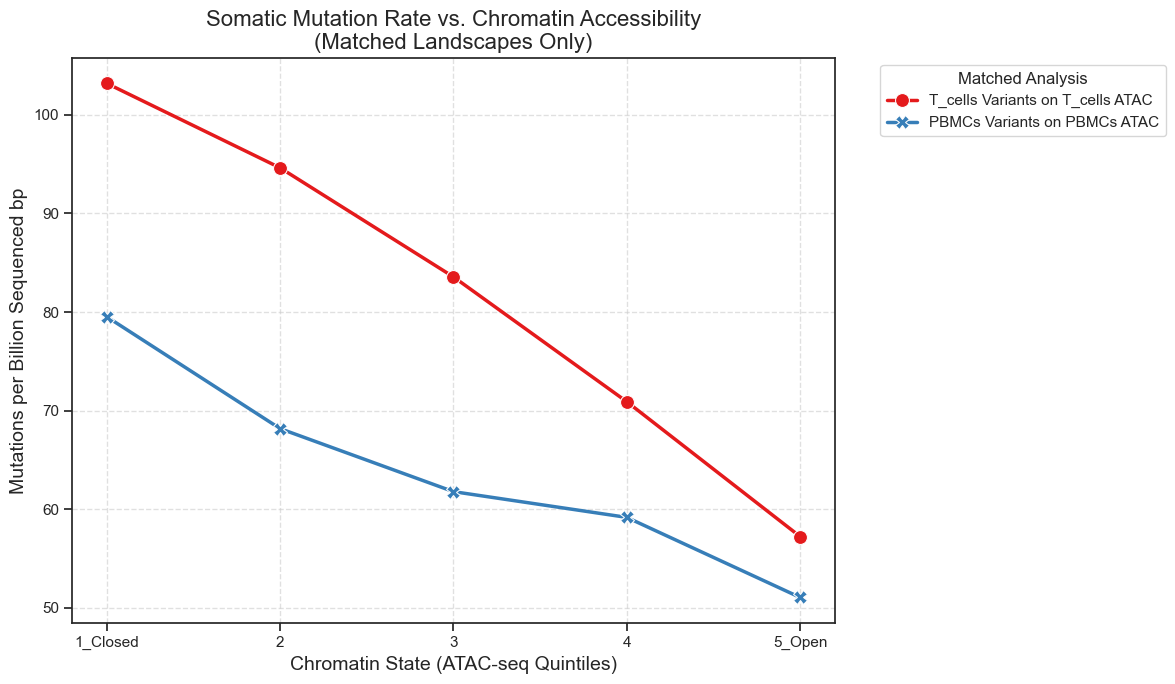

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# FIX 1: Filter df_plot_rates using its own 'Is_Matched' column
df_matched_only = df_plot_rates[df_plot_rates['Is_Matched'] == True]

sns.lineplot(
    data=df_matched_only, 
    x='Quintile', 
    y='Mutation_Rate_Per_Billion_BP', 
    hue='Test_Type',
    style='Test_Type',  # FIX 2: Style by Test_Type to separate the two remaining lines
    markers=['o', 'X'], # Assigns 'o' to the first line, 'X' to the second
    dashes=False,       # Forces all lines to be solid
    linewidth=2.5,
    markersize=10,
    palette='Set1'
)

plt.title('Somatic Mutation Rate vs. Chromatin Accessibility\n(Matched Landscapes Only)', fontsize=16)
plt.ylabel('Mutations per Billion Sequenced bp', fontsize=14)
plt.xlabel('Chromatin State (ATAC-seq Quintiles)', fontsize=14)

# Clean up legend
handles, labels = plt.gca().get_legend_handles_labels()
# FIX 3: Since we only have 2 lines now, we only need indices 1 to 3 (0 is the legend title)
plt.legend( title='Matched Analysis', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_50473/4025889788.py:11: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(


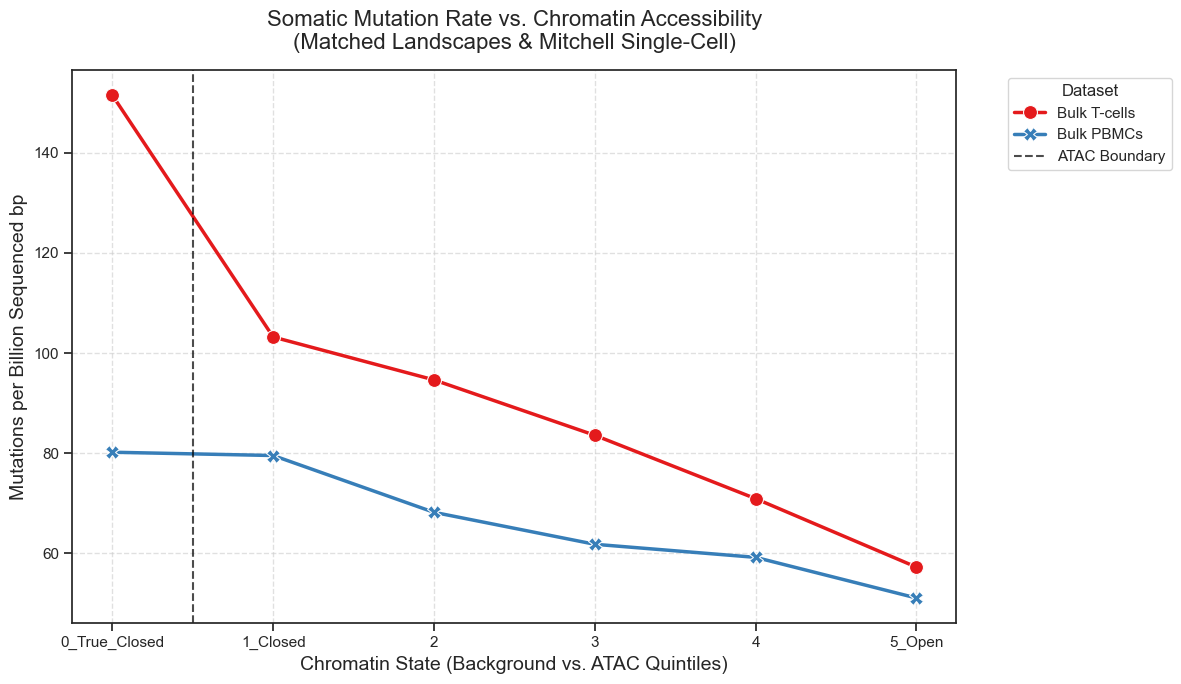

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the ordering is strictly enforced for the categorical X-axis
quintile_order = ['0_True_Closed', '1_Closed', '2', '3', '4', '5_Open']
df_plot_final['Quintile'] = pd.Categorical(df_plot_final['Quintile'], categories=quintile_order, ordered=True)

plt.figure(figsize=(12, 7))

# Plotting with the same markers and style as your reference
sns.lineplot(
    data=df_plot_final, 
    x='Quintile', 
    y='Mutation_Rate_Per_Billion_BP', 
    hue='Test_Group',      # Use the cleaned labels (Bulk T, Bulk PBMC, Mitchell)
    style='Test_Group',  
    markers=['o', 'X', 'D'], 
    dashes=False,       
    linewidth=2.5,
    markersize=10,
    palette='Set1',
    errorbar=None          # Remove CI as requested, showing just the mean trend
)

# The Vertical Bar: Visual separator between background and quintiles
# Position 0.5 is exactly between the 1st and 2nd categorical tick
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='ATAC Boundary')

# Formatting to match your reference style
plt.title('Somatic Mutation Rate vs. Chromatin Accessibility\n(Matched Landscapes & Mitchell Single-Cell)', fontsize=16, pad=15)
plt.ylabel('Mutations per Billion Sequenced bp', fontsize=14)
plt.xlabel('Chromatin State (Background vs. ATAC Quintiles)', fontsize=14)

# Custom legend placement
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_50473/366561666.py:96: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


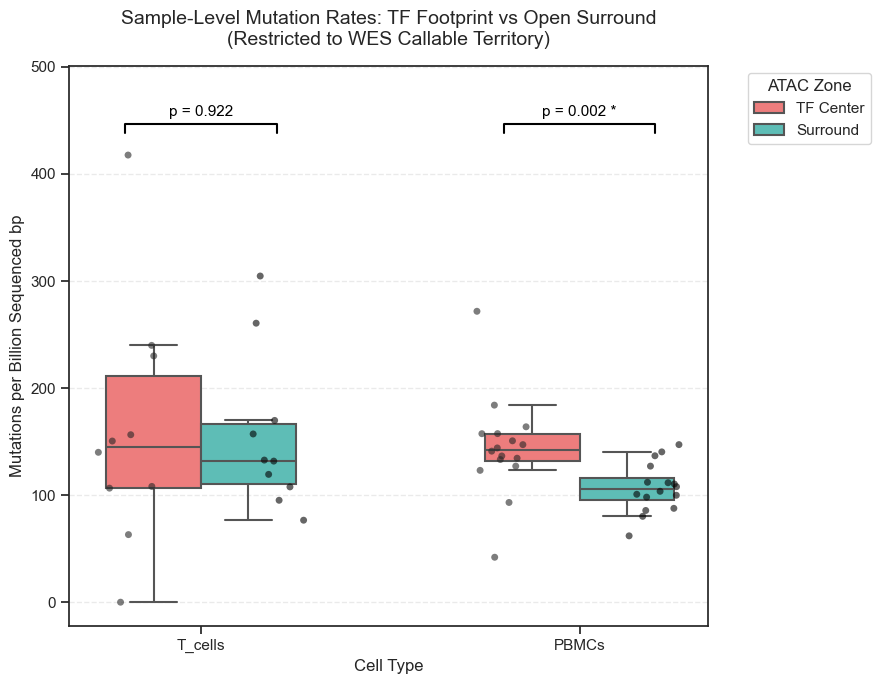

In [34]:
import pandas as pd
import numpy as np
import pyranges as pr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. LOAD YOUR WES TERRITORY ---
df_wes_bed = pd.read_csv(
    '../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed', 
    sep='\t', 
    header=None, 
    usecols=[0, 1, 2],
    names=['Chromosome', 'Start', 'End']
)
pr_wes = pr.PyRanges(df_wes_bed)

# --- 2. DEFINE PRECISE ZONES ---
df_peaks = df_atac.copy()
df_peaks['Center_Pos'] = (df_peaks['Start'] + df_peaks['End']) // 2
df_peaks['Peak_ID'] = df_peaks.index.astype(str) 

df_centers = df_peaks[['Chromosome', 'Center_Pos', 'Peak_ID']].copy()
df_centers['Start'] = df_centers['Center_Pos'] - 15
df_centers['End'] = df_centers['Center_Pos'] + 16
pr_centers = pr.PyRanges(df_centers)

df_1kb = df_peaks[['Chromosome', 'Center_Pos', 'Peak_ID']].copy()
df_1kb['Start'] = df_1kb['Center_Pos'] - 500
df_1kb['End'] = df_1kb['Center_Pos'] + 500
pr_1kb = pr.PyRanges(df_1kb)
pr_surrounds = pr_1kb.subtract(pr_centers)

# --- 3. RESTRICT TO WES CAPTURE TERRITORY ---
valid_centers = pr_centers.intersect(pr_wes).df
valid_surrounds = pr_surrounds.intersect(pr_wes).df

valid_centers['Length'] = valid_centers['End'] - valid_centers['Start']
valid_surrounds['Length'] = valid_surrounds['End'] - valid_surrounds['Start']

total_center_territory = valid_centers['Length'].sum()
total_surround_territory = valid_surrounds['Length'].sum()

# --- 4. MAP MUTATIONS TO VALID ZONES ---
df_vars = df_variants.rename(columns={'CHROM': 'Chromosome'}).copy()
df_vars['Start'] = df_vars['POS'] - 1
df_vars['End'] = df_vars['POS']
pr_vars = pr.PyRanges(df_vars)

muts_in_centers = pr_vars.intersect(pr.PyRanges(valid_centers)).df
muts_in_surrounds = pr_vars.intersect(pr.PyRanges(valid_surrounds)).df

center_counts = muts_in_centers.groupby(['sample_id', 'sample_type']).size().reset_index(name='Center_Muts')
surround_counts = muts_in_surrounds.groupby(['sample_id', 'sample_type']).size().reset_index(name='Surround_Muts')

df_sample_rates = pd.merge(center_counts, surround_counts, on=['sample_id', 'sample_type'], how='outer').fillna(0)

# --- 5. CALCULATE SAMPLE-LEVEL RATES ---
sample_avg_depths = df_variants.groupby('sample_id')['DEPTH'].mean().to_dict()
df_sample_rates['Depth'] = df_sample_rates['sample_id'].map(sample_avg_depths)

df_sample_rates['Center_Rate'] = (df_sample_rates['Center_Muts'] / (total_center_territory * df_sample_rates['Depth'])) * 1e9
df_sample_rates['Surround_Rate'] = (df_sample_rates['Surround_Muts'] / (total_surround_territory * df_sample_rates['Depth'])) * 1e9

# --- 6. STATISTICAL TESTING ---
df_stats = df_sample_rates[df_sample_rates['sample_type'].isin(['T_cells', 'PBMCs'])].copy()

p_values = {}
for cell_type in ['T_cells', 'PBMCs']:
    group_data = df_stats[df_stats['sample_type'] == cell_type]
    try:
        stat, p_val = stats.wilcoxon(group_data['Center_Rate'], group_data['Surround_Rate'])
        p_values[cell_type] = p_val
    except ValueError:
        p_values[cell_type] = 1.0

# --- 7. PLOT PREP ---
plot_df = df_stats.melt(
    id_vars=['sample_id', 'sample_type'],
    value_vars=['Center_Rate', 'Surround_Rate'],
    var_name='Region_Type',
    value_name='Mut_Rate_Per_Billion_Seq_BP'
)
plot_df['Region_Type'] = plot_df['Region_Type'].replace({'Center_Rate': 'TF Center', 'Surround_Rate': 'Surround'})

# --- 8. PLOTTING ---
plt.figure(figsize=(9, 7))

# Draw the boxes and points
sns.boxplot(
    data=plot_df, x='sample_type', y='Mut_Rate_Per_Billion_Seq_BP', 
    hue='Region_Type', palette=['#FF6B6B', '#4ECDC4'],
    showfliers=False, width=0.5, linewidth=1.5
)

sns.stripplot(
    data=plot_df, x='sample_type', y='Mut_Rate_Per_Billion_Seq_BP', 
    hue='Region_Type', dodge=True, alpha=0.6, jitter=0.15, color='black'
)

# --- ADD SIGNIFICANCE BRACKETS ---
# Find the highest point on the plot to place the brackets nicely above the data
y_max = plot_df['Mut_Rate_Per_Billion_Seq_BP'].max()
y_base = y_max * 1.05
h = y_max * 0.02 # Height of the little downward ticks on the bracket

# X-axis positions: T_cells are at 0, PBMCs at 1. The hue offset is ~0.2
positions = {'T_cells': 0, 'PBMCs': 1}

for cell_type, x_center in positions.items():
    p_val = p_values.get(cell_type, 1.0)
    
    # Format the text (e.g., uses scientific notation for tiny p-values, or standard for large)
    p_text = f"p = {p_val:.3e}" if p_val < 0.001 else f"p = {p_val:.3f}"
    if p_val < 0.05:
        p_text += " *" # Add a star for visual quick-reference
        
    x1, x2 = x_center - 0.2, x_center + 0.2
    
    # Draw the bracket: [down-left, up-left, up-right, down-right]
    plt.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1.5, c='black')
    
    # Add the text just above the bracket
    plt.text((x1+x2)*.5, y_base+h+ (y_max*0.01), p_text, ha='center', va='bottom', color='black', fontsize=11)

# Set Y limit a bit higher to make room for the brackets
plt.ylim(top=y_max * 1.2)

plt.title('Sample-Level Mutation Rates: TF Footprint vs Open Surround\n(Restricted to WES Callable Territory)', fontsize=14, pad=15)
plt.ylabel('Mutations per Billion Sequenced bp', fontsize=12)
plt.xlabel('Cell Type', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='ATAC Zone', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

In [12]:
# 1. Create a unique identifier for every mutation in both dataframes
# Format: chr_pos_ref_alt_sample
def make_var_id(df, chr_col):
    return df[chr_col].astype(str) + '_' + df['POS'].astype(str) + '_' + \
           df['REF'] + '_' + df['ALT'] + '_' + df['sample_id']

df_variants['Var_ID'] = make_var_id(df_variants, 'CHROM')
# annotated_variants comes from our earlier 1000bp expanded intersection
annotated_variants['Var_ID'] = make_var_id(annotated_variants, 'Chromosome')

# 2. Get a set of IDs that successfully mapped to the ATAC footprint
atac_accessible_ids = set(annotated_variants['Var_ID'])

# 3. Annotate the master dataframe
df_variants['Chromatin_Context'] = np.where(
    df_variants['Var_ID'].isin(atac_accessible_ids), 
    'ATAC_Accessible', 
    '0_True_Closed'
)

# 4. Verify the split
print("--- Variants Ready for Signature Extraction ---")
display(pd.crosstab(df_variants['sample_type'], df_variants['Chromatin_Context']))

# Now you can easily filter df_variants and export to VCF/CSV for SigProfiler:
# df_closed = df_variants[df_variants['Chromatin_Context'] == '0_True_Closed']

--- Variants Ready for Signature Extraction ---


Chromatin_Context,0_True_Closed,ATAC_Accessible
sample_type,,
PBMCs,6147,4516
T_cells,9472,6819
cord,1052,801


In [13]:
import pandas as pd
import numpy as np
from pyfaidx import Fasta

# Point this to your hg38 reference genome
fasta_path = "/Users/marcodupuisrodriguez/Documents/PhD/VCS/Marco_sequencing_data_and_variant_processing/reference_genome/GRCh38.primary_assembly.genome.fa" 
ref_fasta = Fasta(fasta_path)

# Helper function to get standardized Pyrimidine context
def get_96_context(row):
    chrom = str(row['CHROM'])
    # Handle 'chr' prefix if your FASTA expects it, or strip it if it doesn't
    if not chrom.startswith('chr'): 
        chrom = 'chr' + chrom
        
    pos = row['POS']
    ref = row['REF']
    alt = row['ALT']
    
    # Filter out indels (we only want Single Base Substitutions)
    if len(ref) > 1 or len(alt) > 1:
        return np.nan
        
    try:
        # pyfaidx uses 0-based, half-open intervals. 
        # For POS, the base itself is at POS-1. We want POS-2 to POS+1
        tri_seq = ref_fasta[chrom][pos-2:pos+1].seq.upper()
    except KeyError:
        return np.nan # Chromosome not found
        
    if len(tri_seq) != 3 or tri_seq[1] != ref:
        return np.nan # Reference mismatch or edge of chromosome
        
    # Standardize to Pyrimidine context (C or T)
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'N': 'N'}
    
    if ref in ['C', 'T']:
        mut_type = f"{ref}>{alt}"
        context = f"{tri_seq[0]}[{mut_type}]{tri_seq[2]}"
    else:
        # Reverse complement if the reference is A or G
        mut_type = f"{complement[ref]}>{complement[alt]}"
        rev_tri = "".join([complement[b] for b in reversed(tri_seq)])
        context = f"{rev_tri[0]}[{mut_type}]{rev_tri[2]}"
        
    return context

# Apply the function (this might take a minute or two depending on variant count)
print("Extracting reference contexts...")
df_variants['Context_96'] = df_variants.apply(get_96_context, axis=1)

# Drop any indels or unmapped bases
df_sbs = df_variants.dropna(subset=['Context_96']).copy()
print(f"Extracted contexts for {len(df_sbs)} Single Base Substitutions.")

Extracting reference contexts...
Extracted contexts for 28807 Single Base Substitutions.


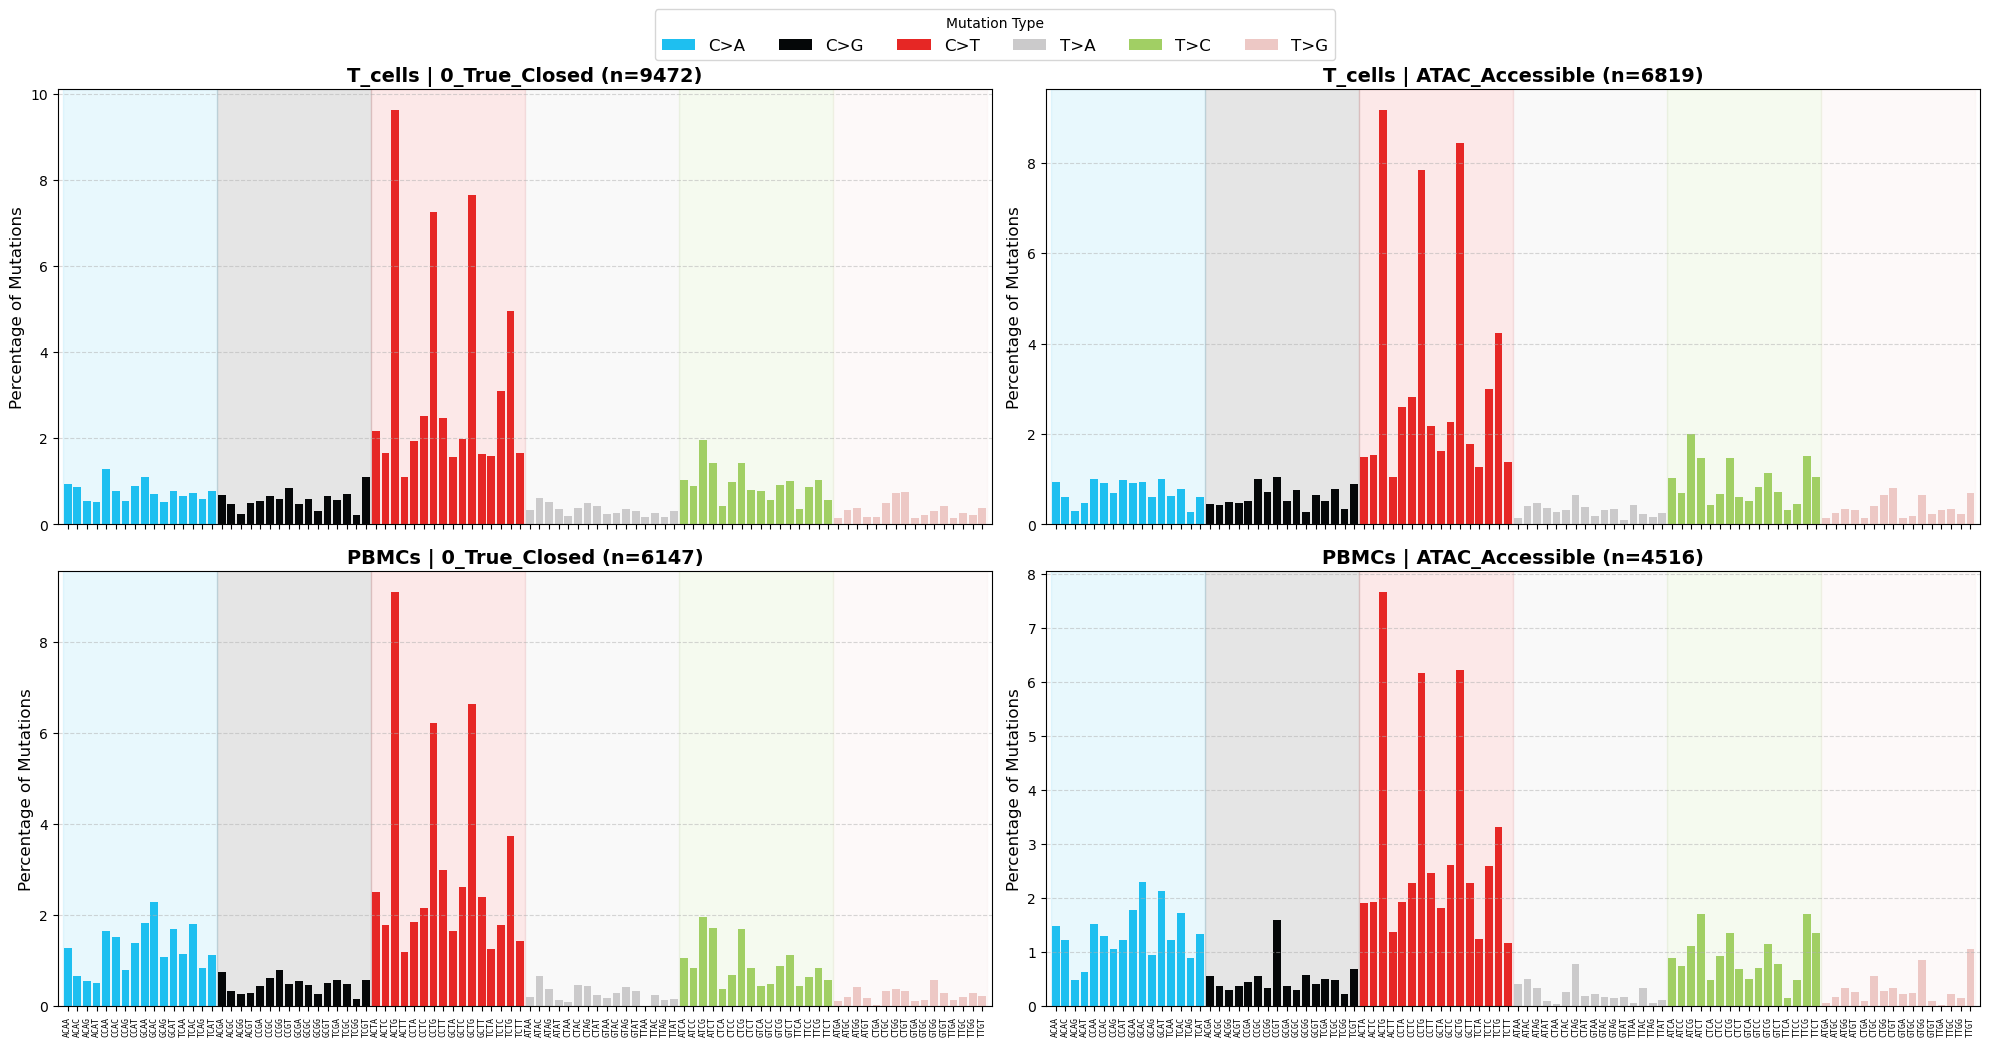

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# 1. Define the exact COSMIC 96 order and colors
mut_types = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
colors = ['#1ebff0', '#050708', '#e62725', '#cbcacb', '#a1cf64', '#edc8c5']
bases = ['A', 'C', 'G', 'T']

# Generate the 96 categories in the exact canonical order
categories_96 = []
for mut in mut_types:
    for upstream in bases:
        for downstream in bases:
            categories_96.append(f"{upstream}[{mut}]{downstream}")

# 2. Prepare the figure
fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=True)
axes = axes.flatten()

combinations = [
    ('T_cells', '0_True_Closed'),
    ('T_cells', 'ATAC_Accessible'),
    ('PBMCs', '0_True_Closed'),
    ('PBMCs', 'ATAC_Accessible')
]

for idx, (cell, context) in enumerate(combinations):
    ax = axes[idx]
    
    # Filter data
    subset = df_sbs[(df_sbs['sample_type'] == cell) & (df_sbs['Chromatin_Context'] == context)]
    
    # Count frequencies
    counts = subset['Context_96'].value_counts().reindex(categories_96).fillna(0)
    
    # Normalize to proportions (Percentages)
    if counts.sum() > 0:
        props = (counts / counts.sum()) * 100
    else:
        props = counts
        
    # Plot bars with correct COSMIC colors
    x_positions = np.arange(96)
    for i, mut in enumerate(mut_types):
        start_idx = i * 16
        end_idx = (i + 1) * 16
        ax.bar(x_positions[start_idx:end_idx], props.iloc[start_idx:end_idx], 
               color=colors[i], width=0.8, label=mut if idx == 0 else "")
               
    # Formatting
    ax.set_title(f"{cell} | {context} (n={len(subset)})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage of Mutations', fontsize=12)
    ax.set_xlim(-1, 96)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Only show x-ticks on the bottom row to save space
    if idx >= 2:
        ax.set_xticks(x_positions)
        ax.set_xticklabels([c.replace('[', '').replace(']', '').replace('>', '') for c in categories_96], 
                           rotation=90, fontsize=6, family='monospace')
        
    # Add colored background bands for visual grouping
    for i in range(6):
        ax.axvspan(i*16 - 0.5, (i+1)*16 - 0.5, color=colors[i], alpha=0.1, zorder=-1)

# Add a single legend to the figure
fig.legend(title="Mutation Type", loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=6, fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

# ─────────────────────────────────────────────────────────────────
# 0. Helper — BED intersection (From your earlier code)
# ─────────────────────────────────────────────────────────────────
def filter_variants_by_bed(df_variants, bed_path):
    """
    Keeps only variants whose POS (1-based) falls inside a BED interval
    (0-based half-open [start, end)).
    """
    bed = pd.read_csv(
        bed_path, sep='\t', header=None, comment='#',
        usecols=[0, 1, 2], names=['CHROM', 'START', 'END'],
        dtype={'CHROM': str, 'START': int, 'END': int}
    )

    df = df_variants.copy()
    bed['_chrom'] = bed['CHROM'].str.lstrip('chr')
    df['_chrom']  = df['CHROM'].astype(str).str.lstrip('chr')

    keep = pd.Series(False, index=df.index)

    for chrom, cb in bed.groupby('_chrom'):
        cb_sorted = cb.sort_values('START')
        starts = cb_sorted['START'].values   # 0-based inclusive
        ends   = cb_sorted['END'].values     # 0-based exclusive

        mask = df['_chrom'] == chrom
        if not mask.any():
            continue

        pos0 = df.loc[mask, 'POS'].values - 1   # convert to 0-based

        # Last interval whose start <= pos0
        idx = np.searchsorted(starts, pos0, side='right') - 1

        in_bed = np.zeros(len(pos0), dtype=bool)
        valid  = idx >= 0
        in_bed[valid] = pos0[valid] < ends[idx[valid]]

        keep.loc[df[mask].index] = in_bed

    n_before = len(df_variants)
    n_after  = int(keep.sum())
    print(f"  BED filter: {n_before:,} → {n_after:,} variants "
          f"({n_after/n_before*100:.1f}% retained)")

    return df.drop(columns=['_chrom'])[keep]


# ─────────────────────────────────────────────────────────────────
# 1. Load and Parse Single-Cell Data
# ─────────────────────────────────────────────────────────────────
print("Loading Mitchell single-cell data...")
df_sc = pd.read_csv("../../data/mitchell_sfs/mitchell_cellular_fractions.csv")

# Split the 'mutation_id' to extract CHROM and POS
# format is '1-100007740-C-T' -> [CHROM, POS, REF, ALT]
df_sc[['CHROM', 'POS', 'REF', 'ALT']] = df_sc['mutation_id'].str.split('-', expand=True)

# Ensure POS is an integer for the BED filter
df_sc['POS'] = df_sc['POS'].astype(int)

# ─────────────────────────────────────────────────────────────────
# 2. Filter by BED (Restrict to Exome)
# ─────────────────────────────────────────────────────────────────
bed_hg19_path = Path("/Users/marcodupuisrodriguez/Documents/PhD/VCS/Duplex_variant_caller/resources/hg19_exome_panel.bed")
print("Applying WES BED filter to single-cell data (hg19)...")
df_sc_wes = filter_variants_by_bed(df_sc, bed_hg19_path)

mitchell_ages = {
    "AX001": 63, 
    "KX001": 29, 
    "KX002": 38,
    "KX008": 76,
    "KX004": 77,
    "CB001": 0.75,
    "CB002": 0.75
}

# ─────────────────────────────────────────────────────────────────
# 3. Downsampling & SFS Parameters
# ─────────────────────────────────────────────────────────────────
TARGET_COLONIES = 50
COLONY_PASS_RATIO = 0.95

# Filter samples based on total colonies sequenced
samples_to_keep = []
for patient_id, group in df_sc_wes.groupby('patient_id'):
    pct_above_target = (group['total_colonies'] >= TARGET_COLONIES).mean()
    if pct_above_target >= COLONY_PASS_RATIO:
        samples_to_keep.append(patient_id)
    else:
        print(f"Discarding {patient_id}: only {pct_above_target:.1%} variants >= {TARGET_COLONIES} colonies")

df_filtered = df_sc_wes[df_sc_wes['patient_id'].isin(samples_to_keep)].copy()

# ─────────────────────────────────────────────────────────────────
# 4. Binomial downsampling for comparable SFS
# ─────────────────────────────────────────────────────────────────
print("Downsampling variants...")

# Hard filter to remove early embryonic/massive clones
# Bulk VAF 0.20 equates to a Cellular Fraction of 0.40
df_filtered = df_filtered[df_filtered['cellular_fraction'] <= 0.40].copy()

# Draw new variant colony counts from a Binomial(TARGET_COLONIES, original_cellular_fraction)
df_filtered['shared_norm'] = np.random.binomial(n=TARGET_COLONIES, p=df_filtered['cellular_fraction'])
df_filtered['total_norm'] = TARGET_COLONIES
df_filtered['cf_norm'] = df_filtered['shared_norm'] / TARGET_COLONIES

# Remove variants that downsampled to 0 colonies (lost variants)
df_norm = df_filtered[df_filtered['shared_norm'] > 0].copy()



Loading Mitchell single-cell data...
Applying WES BED filter to single-cell data (hg19)...
  BED filter: 1,403,557 → 16,741 variants (1.2% retained)
Downsampling variants...


In [16]:
from pyliftover import LiftOver

print("Lifting over all Mitchell variants (no downsampling) to hg38...")
lo = LiftOver('hg19', 'hg38')

def liftover_variant(row):
    chrom = row['CHROM'] if row['CHROM'].startswith('chr') else f"chr{row['CHROM']}"
    pos_0based = row['POS'] - 1
    new_coords = lo.convert_coordinate(chrom, pos_0based)
    if new_coords:
        return pd.Series([new_coords[0][0], new_coords[0][1] + 1])
    return pd.Series([np.nan, np.nan])

# Apply to the full WES-filtered set
df_sc_wes[['CHROM_hg38', 'POS_hg38']] = df_sc_wes.apply(liftover_variant, axis=1)
df_sc_hg38 = df_sc_wes.dropna(subset=['CHROM_hg38']).copy()
df_sc_hg38['POS_hg38'] = df_sc_hg38['POS_hg38'].astype(int)

print(f"Total variants for analysis: {len(df_sc_hg38):,}")

Lifting over all Mitchell variants (no downsampling) to hg38...
Total variants for analysis: 16,741


In [17]:
import pyranges as pr
import itertools

# --- A. Prepare ATAC Quintiles (PBMC matched) ---
df_atac_pbmc = df_atac_wes.copy()
df_atac_pbmc['Quintile'] = pd.qcut(df_atac_pbmc['PBMCs_accessibility'], q=5, labels=[1, 2, 3, 4, 5])
df_atac_pbmc['Length'] = df_atac_pbmc['End'] - df_atac_pbmc['Start']
territory_per_q = df_atac_pbmc.groupby('Quintile')['Length'].sum().reset_index(name='Territory_BP')
pr_pbmc_atac = pr.PyRanges(df_atac_pbmc[['Chromosome', 'Start', 'End', 'Quintile']])

# --- B. Prepare Variants ---
df_sc_hg38['Start'] = df_sc_hg38['POS_hg38'] - 1
df_sc_hg38['End'] = df_sc_hg38['POS_hg38']
pr_sc = pr.PyRanges(df_sc_hg38.rename(columns={'CHROM_hg38': 'Chromosome'}))

# --- C. Join and Count ---
sc_hits = pr_sc.join(pr_pbmc_atac).df

# Get total colonies per patient (using mean in case of slight per-variant record variations)
patient_colony_counts = df_sc_hg38.groupby('patient_id')['total_colonies'].mean().to_dict()

# Create patient x quintile grid
patients = df_sc_hg38['patient_id'].unique()
df_plot_sc = pd.DataFrame(list(itertools.product(patients, [1,2,3,4,5])), columns=['patient_id', 'Quintile'])

# Count mutations
counts = sc_hits.groupby(['patient_id', 'Quintile']).size().reset_index(name='Mutations')
df_plot_sc = pd.merge(df_plot_sc, counts, on=['patient_id', 'Quintile'], how='left').fillna(0)
df_plot_sc = pd.merge(df_plot_sc, territory_per_q, on='Quintile')

# --- D. THE REAL NORMALIZATION ---
# Rate = Muts / (Territory * (2 * Colonies)) * 1e9
df_plot_sc['Colony_Depth'] = df_plot_sc['patient_id'].map(patient_colony_counts) * 2
df_plot_sc['Mutation_Rate_Per_Billion_BP'] = (
    df_plot_sc['Mutations'] / (df_plot_sc['Territory_BP'] * df_plot_sc['Colony_Depth'])
) * 1e9

df_plot_sc['Test_Type'] = 'Mitchell PBMCs (Full Colony Data)'

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_50473/1431318578.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  territory_per_q = df_atac_pbmc.groupby('Quintile')['Length'].sum().reset_index(name='Territory_BP')
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_50473/1431318578.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = sc_hits.groupby(['patient_id', 'Quintile']).size().reset_index(name='Mutations')
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_50473/1431318578.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecate

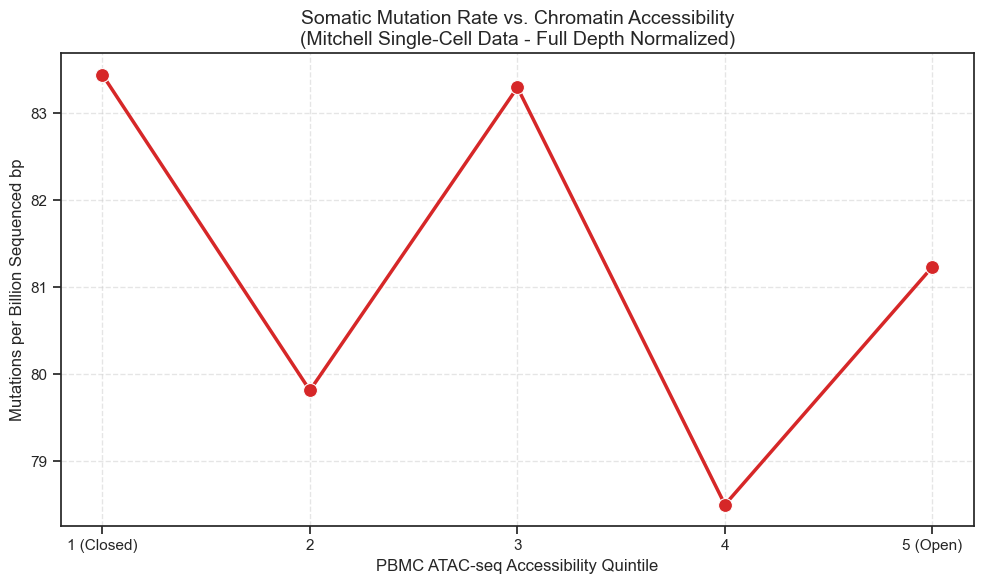

In [18]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot_sc, 
    x='Quintile', 
    y='Mutation_Rate_Per_Billion_BP', 
    marker='o',
    linewidth=2.5,
    markersize=10,
    color='#d62728', # Classic Red
    errorbar=None
)

# Use your custom labels if preferred (e.g., 1_Closed to 5_Open)
plt.xticks([1, 2, 3, 4, 5], ['1 (Closed)', '2', '3', '4', '5 (Open)'])

plt.title('Somatic Mutation Rate vs. Chromatin Accessibility\n(Mitchell Single-Cell Data - Full Depth Normalized)', fontsize=14)
plt.ylabel('Mutations per Billion Sequenced bp', fontsize=12)
plt.xlabel('PBMC ATAC-seq Accessibility Quintile', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
# 1. Prepare Bulk Data (Assuming df_plot_rates contains your T-cell and PBMC bulk results)
df_bulk_matched = df_plot_rates[df_plot_rates['Is_Matched'] == True].copy()

# 2. Prepare Mitchell Data (From the previous step)
df_mitchell_matched = df_plot_sc.copy()
# Ensure 'Test_Type' is descriptive for the legend
df_mitchell_matched['Test_Type'] = 'Mitchell PBMCs (Single-Cell)'

# 3. Concatenate
df_combined_all = pd.concat([df_bulk_matched, df_mitchell_matched], ignore_index=True)

# 4. Standardize Quintiles
# Use a regex to grab the digit from strings like '1_Closed' or '5_Open'
df_combined_all['Quintile'] = (
    df_combined_all['Quintile']
    .astype(str)
    .str.extract('(\d+)')
    .astype(int)
)

print("Quintiles standardized to clean integers 1-5.")

Quintiles standardized to clean integers 1-5.


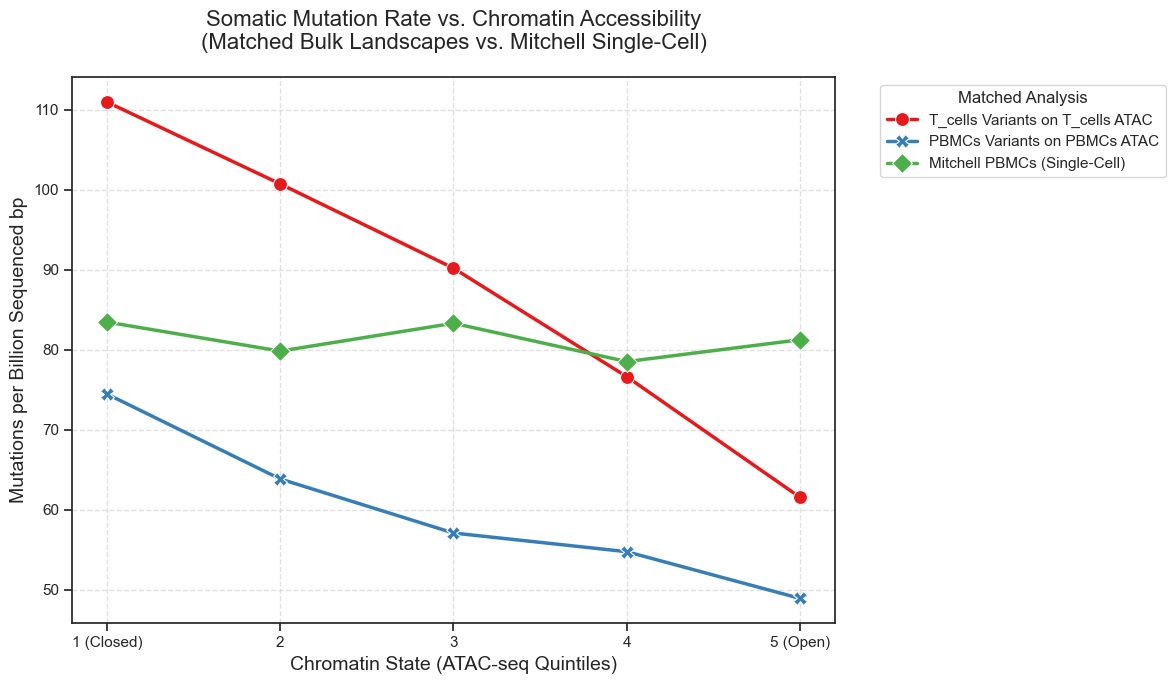

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# We use 'Test_Type' for both hue and style to differentiate the 3 datasets
sns.lineplot(
    data=df_combined_all, 
    x='Quintile', 
    y='Mutation_Rate_Per_Billion_BP', 
    hue='Test_Type',
    style='Test_Type',
    markers=['o', 'X', 'D'], # Circle for Bulk T, Cross for Bulk PBMC, Diamond for Mitchell
    dashes=False,
    linewidth=2.5,
    markersize=10,
    palette='Set1',
    errorbar=None
)

# Formatting
plt.title('Somatic Mutation Rate vs. Chromatin Accessibility\n(Matched Bulk Landscapes vs. Mitchell Single-Cell)', fontsize=16, pad=20)
plt.ylabel('Mutations per Billion Sequenced bp', fontsize=14)
plt.xlabel('Chromatin State (ATAC-seq Quintiles)', fontsize=14)

# Force X-axis labels to be clean and descriptive
plt.xticks([1, 2, 3, 4, 5], ['1 (Closed)', '2', '3', '4', '5 (Open)'])

# Clean up the legend and move it outside
plt.legend(title='Matched Analysis', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()